## 1. Import dataset

In [1]:
import os
import sys

sys.path.append(os.path.abspath(".."))   # Add root path to sys.path
os.chdir("..")  # Change working directory to root path

In [2]:
import pandas as pd

data_path = "data/processed/covariant_owid_imputed.csv"
original_df = pd.read_csv(data_path)

original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11671 entries, 0 to 11670
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   iso_code                        11671 non-null  object 
 1   continent                       11671 non-null  object 
 2   location                        11671 non-null  object 
 3   date                            11671 non-null  object 
 4   new_cases_smoothed_per_million  11671 non-null  float64
 5   population                      11671 non-null  float64
 6   median_age                      11671 non-null  float64
 7   classification                  11671 non-null  object 
 8   Overall_score                   11671 non-null  float64
 9   group                           11671 non-null  object 
 10  total_sequence                  11671 non-null  int64  
 11  recombinant                     9713 non-null   float64
 12  20A                             

## 2. Process columns

In [4]:
# Country-identifier columns
index_columns = ['iso_code', 'location']

# OWID columns
time_varying_columns = ['total_tests_per_thousand', 'people_vaccinated_per_hundred', 'stringency_index']
time_fixed_columns = ['population', 'median_age', 'Overall_score', 'date']
categorical_columns = ['continent', 'classification', 'group']

# Covariant columns (variants and recombinant)
original_covariant_columns = [
                        '20A', '20B', '20C', '20E', 'recombinant',
                        'Beta', 'Alpha', 'Delta', 'Epsilon', 'Eta',
                        'Iota', 'Lambda', 'Mu', 'Omicron', 'S:677',
                        'Gamma', 'Kappa'
                    ]
constraint_columns = ['total_sequence']

total_columns = index_columns + time_varying_columns + time_fixed_columns + categorical_columns + original_covariant_columns + constraint_columns

for col in total_columns:
    if col not in original_df.columns:
        print(f"Column '{col}' is missing from the DataFrame.")

for col in original_df.columns:
    if col not in total_columns:
        print(f"Column '{col}' is unexpected and not categorized.")

len(total_columns)

Column 'new_cases_smoothed_per_million' is unexpected and not categorized.


30

### 2.1 Preprocess data to numeric types

In [5]:
processed_df = original_df.copy()

# process date column
processed_df['date'] = pd.to_datetime(processed_df['date'], format='%Y-%m-%d')
first_date = processed_df['date'].min()
processed_df['date'] = (processed_df['date'] - first_date).dt.days

# process categorical columns => one-hot encoding
categiorical_columns = [c for c in processed_df.columns if processed_df[c].dtype == 'object' and c not in index_columns]
encoded_categorial_columns = []

for c in categiorical_columns:
    dummies = pd.get_dummies(processed_df[c], prefix=c)

    # drop the first dummy column to avoid multicollinearity
    dummies.drop(columns=dummies.columns[0], inplace=True)
    encoded_categorial_columns.extend(dummies.columns)
    
    dummies = dummies.astype(int)
    processed_df = pd.concat([processed_df, dummies], axis=1)
    processed_df.drop(columns=[c], inplace=True)

# process covariant columns => add prefix "covariant_"
for c in original_covariant_columns:
    processed_df.rename(columns={c: f"covid_{c}"}, inplace=True)

covariant_columns = [f"covid_{c}" for c in original_covariant_columns]

processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11671 entries, 0 to 11670
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_code                            11671 non-null  object 
 1   location                            11671 non-null  object 
 2   date                                11671 non-null  int64  
 3   new_cases_smoothed_per_million      11671 non-null  float64
 4   population                          11671 non-null  float64
 5   median_age                          11671 non-null  float64
 6   Overall_score                       11671 non-null  float64
 7   total_sequence                      11671 non-null  int64  
 8   covid_recombinant                   9713 non-null   float64
 9   covid_20A                           7661 non-null   float64
 10  covid_20B                           4545 non-null   float64
 11  covid_20C                           2220 

### 2.3 Check imputable status

**Idea**: Within a row, if sum of the every non-missing covariant equals total_sequence, then the missing value is surely zero.

$\rightarrow$ Directly impute zero for these cases, and remove them from the missing list.

In [6]:
from tqdm import tqdm

count = 0

for index, row in tqdm(processed_df.iterrows(), total=processed_df.shape[0], desc="Checking imputable status"):
    non_missing_sum = row[covariant_columns].sum()
    total_sequence = row['total_sequence']

    if non_missing_sum == total_sequence:
        count += 1
        for covariant in covariant_columns:
            if pd.isna(row[covariant]):
                processed_df.at[index, covariant] = 0

print(f"Number of filled rows: {count}")
processed_df.info()

Checking imputable status: 100%|██████████| 11671/11671 [00:05<00:00, 2173.74it/s]

Number of filled rows: 7850
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11671 entries, 0 to 11670
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_code                            11671 non-null  object 
 1   location                            11671 non-null  object 
 2   date                                11671 non-null  int64  
 3   new_cases_smoothed_per_million      11671 non-null  float64
 4   population                          11671 non-null  float64
 5   median_age                          11671 non-null  float64
 6   Overall_score                       11671 non-null  float64
 7   total_sequence                      11671 non-null  int64  
 8   covid_recombinant                   11011 non-null  float64
 9   covid_20A                           10519 non-null  float64
 10  covid_20B                           9534 non-null   float64
 11  covid_20C    

### 2.2 Find missing columns and its missing part

In [7]:
from dataclasses import dataclass

@dataclass
class MissingColumn:
    name: str
    missing_indices: pd.Index

missing_columns = [MissingColumn(name=c, missing_indices=processed_df[processed_df[c].isnull()].index) for c in processed_df.columns if processed_df[c].isnull().any()]
missing_columns[0].missing_indices[:10]

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64')

## 3. Define classes for imputation process

### 3.1 VariableModel classes

In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings

from src.variables.base import VariableModel, Parameter
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialResultsWrapper, ZeroInflatedNegativeBinomialP
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from scipy.stats import nbinom
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


class ZINBVariableModel(VariableModel):
    name: str
    missing_indices: pd.Index
    zi_predictors: list[str]
    nb_predictors: list[str]
    selected_zi_predictors: list[str]   # for feature selection
    selected_nb_predictors: list[str]   # for feature selection
    fitted_results: ZeroInflatedNegativeBinomialResultsWrapper
    zi_scaler: StandardScaler
    nb_scaler: StandardScaler

    def __init__(self, name: str, missing_indices: pd.Index, zi_predictors: list[str], nb_predictors: list[str]):
        self.name = name
        self.missing_indices = missing_indices
        self.zi_predictors = zi_predictors
        self.nb_predictors = nb_predictors
        self.selected_zi_predictors = zi_predictors
        self.selected_nb_predictors = nb_predictors
        self.zi_scaler = StandardScaler()
        self.nb_scaler = StandardScaler()
    
    def select_predictors(
            self, X: pd.DataFrame, y: pd.Series, 
            is_classification: bool = False, top_k: int = 5
        ) -> list[str]:
        """
        Select top predictors using Random Forest feature importance. For classification, use RandomForestClassifier; for regression, use RandomForestRegressor.
        """
        if is_classification:
            model = RandomForestClassifier(n_estimators=100, random_state=42)
        else:
            model = RandomForestRegressor(n_estimators=100, random_state=42)
        
        model.fit(X, y)
        importances = model.feature_importances_

        selected_idx = np.argsort(importances)[-top_k:]   # top-k
        return X.columns[selected_idx].tolist()
    

    def fit(self, imputed_data: pd.DataFrame, selected: bool = False) ->    list[Parameter]:
        """
        Input: data is the imputed dataset of the previous iteration.
        Return: parameters of the current distribution and fitted values for the missing indices.
        """
        rows = imputed_data.drop(index=self.missing_indices).copy()

        if selected:
            # ZI
            self.selected_zi_predictors = self.select_predictors(
                rows[self.zi_predictors],
                (rows[self.name] == 0).astype(int),
                is_classification=True
            )

            # NB
            positive_mask = rows[self.name] > 0
            min_samples = 30    # fix this threshold

            if positive_mask.sum() > min_samples:
                X_nb = rows.loc[positive_mask, self.nb_predictors]
                y_nb = rows.loc[positive_mask, self.name]
            else:
                # fallback
                X_nb = rows[self.nb_predictors]
                y_nb = rows[self.name]
            
            top_k = min(10, int(np.sqrt(X_nb.shape[1])), int(positive_mask.sum() - 1))  # ensure we don't select more predictors than samples
            self.selected_nb_predictors = self.select_predictors(X_nb, y_nb, is_classification=False, top_k=top_k)

        X_train_zi = pd.DataFrame(
            self.zi_scaler.fit_transform(rows[self.selected_zi_predictors]),
            columns=self.selected_zi_predictors,
            index=rows.index
        )

        X_train_nb = pd.DataFrame(
            self.nb_scaler.fit_transform(rows[self.selected_nb_predictors]),
            columns=self.selected_nb_predictors,
            index=rows.index
        )

        X_train_zi = sm.add_constant(X_train_zi)
        X_train_nb = sm.add_constant(X_train_nb)
        y_train = rows[self.name]

        # clip the predictors to avoid extreme values that can cause convergence issues
        X_train_nb = X_train_nb.clip(-5, 5)
        X_train_zi = X_train_zi.clip(-5, 5)

        model = ZeroInflatedNegativeBinomialP(endog=y_train, exog=X_train_nb, exog_infl=X_train_zi, inflation='logit')

        # fit Poisson model to get better starting values for the NB component
        try:
            poisson_res = sm.GLM(y_train, X_train_nb, family=sm.families.Poisson()).fit()
        except Exception:
            # print(f"Error occurred while fitting Poisson model for variable '{self.name}': {e}")
            positive_mask = y_train > 0

            poisson_res = sm.GLM(
                y_train[positive_mask],
                X_train_nb.loc[positive_mask],
                family=sm.families.Poisson()
            ).fit()

        start_params = np.concatenate([
            np.zeros(X_train_zi.shape[1]),
            poisson_res.params,
            [0.1]
        ])
        current_params = start_params

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            converged = False

            for _ in range(5):  # max 5 attempts
                res = model.fit(
                    start_params=current_params,
                    maxiter=50,
                    disp=0,
                    method='lbfgs'
                )

                current_params = res.params.copy()
                converged = res.mle_retvals.get('converged', False)

                if converged:
                    break

            # --- Only handle warning AFTER loop ---
            if not converged:
                print(f"Warning: ZINB model did not converge after {5 * 50} iterations for variable '{self.name}'.")

            self.fitted_results = res
        
        # enforce safe alpha
        params = res.params.copy()
        if "alpha" in params:
            params["alpha"] = max(params["alpha"], 1e-6)

        self.fitted_results.params[:] = params

        # Extract and return the fitted parameters
        parameters = []
        for name, value in self.fitted_results.params.items():
            if name.startswith("inflate_"):
                name = name[len("inflate_"):]
                component = "zi"
            else:
                component = "nb"
            
            parameters.append(Parameter(name=name, value=value, component=component))

        ## Non selected predictors have zero coefficients
        for c in self.zi_predictors:
            if c not in self.selected_zi_predictors:
                parameters.append(Parameter(name=c, value=0.0, component="zi"))
        
        for c in self.nb_predictors:
            if c not in self.selected_nb_predictors:
                parameters.append(Parameter(name=c, value=0.0, component="nb"))

        return parameters

    def sample(self, imputed_data: pd.DataFrame) -> pd.Series:
        """
        Isolate the sampling logic to this method, which can be called after fitting the model. 
        This allows us to sample data later.
        """
        # --- Extract rows ---
        rows = imputed_data.loc[self.missing_indices]

        X_zi = pd.DataFrame(
            self.zi_scaler.transform(rows[self.selected_zi_predictors]),
            columns=self.selected_zi_predictors,
            index=rows.index
        )

        X_nb = pd.DataFrame(
            self.nb_scaler.transform(rows[self.selected_nb_predictors]),
            columns=self.selected_nb_predictors,
            index=rows.index
        )

        X_zi = X_zi.clip(-5, 5)
        X_nb = X_nb.clip(-5, 5)

        X_zi = sm.add_constant(X_zi, has_constant='add')
        X_nb = sm.add_constant(X_nb, has_constant='add')

        # --- Model predictions (vectorized) ---
        prob_zero = self.fitted_results.predict(X_nb, exog_infl=X_zi, which='prob-zero')   # shape (n,)
        mu = self.fitted_results.predict(X_nb, exog_infl=X_zi, which='mean-main')          # shape (n,)
        
        prob_zero = np.clip(prob_zero, 1e-6, 1 - 1e-6)  # clip probabilities to avoid extremes
        mu = np.clip(mu, 1e-6, 1e6)     # clip mean to avoid extremes that can cause issues in NB sampling

        # --- Constraint ---
        total_seq = rows["total_sequence"].values

        covariate_columns = [c for c in imputed_data.columns if c.startswith("covid_")]
        covariates = imputed_data[covariate_columns].values
        current_var = imputed_data[self.name].values

        sum_others = covariates.sum(axis=1) - current_var
        sum_others = sum_others[self.missing_indices]

        max_allowed = total_seq - sum_others
        max_allowed = np.maximum(max_allowed, 0.0)

        # --- Zero model ---
        is_zero = np.random.binomial(1, prob_zero)

        # --- Generate NB samples ---
        # --- NB parameters ---
        alpha = self.fitted_results.params.get('alpha', 0.1)
        alpha = max(alpha, 1e-6)

        n_param = 1 / alpha
        p_param = n_param / (n_param + mu)

        # --- Initialize ---
        nb_counts = np.zeros_like(mu, dtype=int)

        # --- Mask: only sample where non-zero AND feasible ---
        valid_mask = (is_zero == 0) & (max_allowed > 0)

        if np.any(valid_mask):
            n_v = n_param
            p_v = p_param[valid_mask]
            M_v = max_allowed[valid_mask].astype(int)

            # Compute CDF at truncation point
            cdf_M = nbinom.cdf(M_v, n_v, p_v)

            # Avoid numerical issues
            cdf_M = np.clip(cdf_M, 1e-12, 1.0)

            # Sample uniform
            u = np.random.uniform(0, cdf_M)

            # Inverse CDF (vectorized)
            nb_counts_valid = nbinom.ppf(u, n_v, p_v)

            nb_counts[valid_mask] = nb_counts_valid.astype(int)
        
        imputed_values = np.where(is_zero == 1, 0, nb_counts)

        return imputed_values.tolist(), prob_zero.tolist(), mu.tolist()

In [9]:
from dataclasses import dataclass, Field
from time import time

@dataclass
class ZINBDistribution:
    pi: float
    mu: float

@dataclass
class VariableRecord:
    name: str
    params: list[Parameter]
    imputed_values: list[float]
    fitting_time: float = 0.0
    distributions: list[ZINBDistribution] = None    # list of estimated distributions for each missing indices

@dataclass
class VariableHistory:
    name: str
    history: list[VariableRecord]
    iterations: list[int]


class ParameterConvergenceChecker:
    convergence_threshold: float

    def __init__(self, convergence_threshold: float = 1e-4):
        self.convergence_threshold = convergence_threshold

    def _params_to_dict(self, params: list[Parameter]) -> dict[tuple, float]:
        """
        Convert parameter list into a dict keyed by (name, component)
        """
        return {(p.name, p.component): p.value for p in params}

    def _compute_param_change(self, prev: dict[tuple, float], curr: dict[tuple, float], eps: float = 1e-6) -> float:
        """
        Compute robust relative change between two parameter dictionaries.
        Returns a scalar summary (mean relative change).
        """
        changes = []

        for key in curr:
            if key in prev:
                prev_val = prev[key]
                curr_val = curr[key]

                denom = abs(prev_val) + eps
                rel_change = abs(curr_val - prev_val) / denom
                changes.append(rel_change)

        if not changes:
            return np.inf

        return float(np.mean(changes))

    def _check_variable_convergence(self, var_history: VariableHistory, window: int = 5) -> tuple[bool, float]:
        """
        Check convergence using a rolling window of size `window`.
        """
        if len(var_history.history) < window + 1:
            return False, float('inf')
        changes = []

        for i in range(-window, 0):
            prev = self._params_to_dict(var_history.history[i - 1].params)
            curr = self._params_to_dict(var_history.history[i].params)

            change = self._compute_param_change(prev, curr)
            changes.append(change)

        mean_change = float(np.mean(changes))

        return mean_change < self.convergence_threshold, mean_change

    def _check_param_convergence(self, variables: dict[str, VariableHistory]) -> tuple[bool, list[tuple[str, float]]]:
        """
        check the convergence of the parameters of the fitted models.
        """
        var_changes = []

        for var_history in variables.values():
            is_converged, mean_change = self._check_variable_convergence(var_history)
            if not is_converged:
                var_changes.append((var_history.name, mean_change))
            
        return len(var_changes) == 0, var_changes

class Tracker:
    variables: dict[str, VariableHistory]
    convergence_threshold: float = 1e-6
    convergence_checker: ParameterConvergenceChecker

    def __init__(self, missing_variables: list[str], convergence_threshold: float = 1e-4):
        self.variables = {
            var_name: VariableHistory(name=var_name, history=[], iterations=[]) for var_name in missing_variables
        }
        self.convergence_threshold = convergence_threshold
        self.convergence_checker = ParameterConvergenceChecker(convergence_threshold=convergence_threshold)

    def record(self, iteration: int, variable_record: VariableRecord):
        var_name = variable_record.name
        self.variables[var_name].history.append(variable_record)
        self.variables[var_name].iterations.append(iteration)

    def get_current_data(self) -> dict[str, list[float]]:
        """
        Return the current imputed dataset (after the latest iteration).
        """
        current_data = {}
        for var_name, var_history in self.variables.items():
            if var_history.history:
                current_data[var_name] = var_history.history[-1].imputed_values
            else:
                raise ValueError(f"No history found for variable '{var_name}'. Cannot get current data.")

        return current_data

    def check_early_stopping(self) -> tuple[bool, list[tuple[str, float]]]:
        return self.convergence_checker._check_param_convergence(self.variables)
    
    def print_iteration_summary(self, iteration: int):
        def _get_param_name(param: Parameter) -> str:
            param_name = str(param.name)
            param_type = param.component

            if param_name.startswith("covid_"):
                param_name = param_name[len("covid_"):]
            param_name = param_name[:5]     # shorten for display
            return f"{param_type}_{param_name}"
        
        variable_records = [var_history.history[iteration] for var_history in self.variables.values() if var_history.history]
        coefficients_matrix = {var_name: {_get_param_name(param): "" for param in var_history.history[0].params} for var_name, var_history in self.variables.items()}

        for var_record in variable_records:
            for param in var_record.params:
                param_name = _get_param_name(param)
                coefficients_matrix[var_record.name][param_name] = f"{param.value:.4f}"

        df = pd.DataFrame(coefficients_matrix).T
        display(df.style.set_caption(f"Iteration {iteration} Parameter Estimates").set_properties(**{'text-align': 'center'}))

In [10]:
from tqdm import tqdm
from time import time

MAX_ITERATIONS = 100
features = covariant_columns + time_varying_columns + time_fixed_columns + encoded_categorial_columns

def check_total_sequence_constraints(full_df: pd.DataFrame) -> bool:
    """
    Check if the total sequence constraints are satisfied.
    """
    # Implementation for checking total sequence constraints
    print(f"Number of rows violating total sequence constraints: {(full_df[covariant_columns].sum(axis=1) > full_df['total_sequence']).sum()}")
    return (full_df[covariant_columns].sum(axis=1) <= full_df['total_sequence']).all()

class FCSEngine:
    variables: list[ZINBVariableModel]
    original_df: pd.DataFrame
    tracker: Tracker
    max_iterations: int = MAX_ITERATIONS

    def __init__(self, variables: list[ZINBVariableModel], original_df: pd.DataFrame, tracker: Tracker, max_iterations: int = MAX_ITERATIONS):
        self.variables = variables
        self.original_df = original_df
        self.tracker = tracker
        self.max_iterations = max_iterations

    def _initialize_imputation(self):
        # Initialize imputation for the variable (e.g., using mean or median)
        df0 = self.original_df.copy()

        for variable in self.variables:
            # fill missing values with mean of the variable
            df0.loc[variable.missing_indices, variable.name] = 0
            self.tracker.record(0, VariableRecord(
                name=variable.name,
                params=[],  # no parameters for initialization
                imputed_values=df0[variable.name].iloc[variable.missing_indices].tolist()
            ))
    
    def get_current_data(self) -> pd.DataFrame:
        """
        Return the current imputed dataset (after the latest iteration).
        """
        current_data_dict = self.tracker.get_current_data() # get the latest imputed values into the tracker
        imputed_df = self.original_df.copy()

        for var_name, imputed_values in current_data_dict.items():
            current_var = self.variables[self.variables.index(next(v for v in self.variables if v.name == var_name))]
            imputed_df.loc[current_var.missing_indices, var_name] = imputed_values

        return imputed_df

    def get_full_data(self, iteration: int) -> pd.DataFrame:
        """
        Return the imputed dataset for the given iteration.
        """
        # get non-missing data from the original dataset
        imputed_df = self.original_df.copy()
        # iteration_record = self.tracker.history[iteration] if iteration < len(self.tracker.history) else None

        # if iteration_record is None:
        #     raise ValueError(f"No imputation record found for iteration {iteration}")

        for missing_var in self.variables:
            var_name = missing_var.name
            missing_indices = missing_var.missing_indices

            if iteration >= len(self.tracker.variables[var_name].history):
                raise ValueError(f"No imputation record found for variable '{var_name}' at iteration {iteration}")
            
            imputed_values = self.tracker.variables[var_name].history[iteration].imputed_values
            imputed_df.loc[missing_indices, var_name] = imputed_values

        return imputed_df

    def _print_header(self):
        print("\n" + "="*88)
        print(f"| ZINB-BASED IMPUTATION PIPELINE ".ljust(87) + "|")
        print(f"| Max Iterations: {self.max_iterations:<4} |")
        print("="*88 + "\n")
    
    def _print_separator(self, width: int = 88):
        print("+" + "-" * (width - 2) + "+")
    
    def _print_iteration_header(self, iteration: int):
        print(f"ITERATION {iteration}/{self.max_iterations-1}".center(88, " "))

    def _print_iteration_summary(self, variable_records: list[VariableRecord]):
        coefficients_matrix = {var_name: {param_name: "" for param_name in features} for var_name in [vr.name for vr in variable_records]}

        for var_record in variable_records:
            for param in var_record.params:
                coefficients_matrix[var_record.name][param.name] = f"{param.value:.2f}"
        
        display_df = pd.DataFrame(coefficients_matrix).T
        display(display_df)
        
        self._print_separator()

    def run(self):
        self._print_header()
        self._initialize_imputation()

        selected_new_columns = True
        
        for iteration in range(1, self.max_iterations):
            self._print_iteration_header(iteration)

            pbar = tqdm(self.variables)
            
            ## Fit the model and sample for each variable
            for variable in pbar:
                # Implementation for running the FCS engine
                begin_time = time()
                pbar.set_description(f"{variable.name} - retrieving data")
                last_imputed_data = self.get_current_data()

                pbar.set_description(f"{variable.name} - fitting")
                parameters = variable.fit(last_imputed_data, selected=selected_new_columns)

                pbar.set_description(f"{variable.name} - sampling")
                imputed_values, prob_zeros, mus = variable.sample(last_imputed_data)
            
                self.tracker.record(iteration, VariableRecord(
                    name=variable.name,
                    params=parameters,
                    imputed_values=imputed_values,
                    fitting_time=time() - begin_time,
                    distributions=[ZINBDistribution(pi=p, mu=m) for p, m in zip(prob_zeros, mus)]
                ))

            # self.tracker.print_iteration_summary(iteration)

            print(f"Checking for convergence...")
            is_converged, var_changes = self.tracker.check_early_stopping()
            if is_converged:
                print(f"Convergence reached at iteration {iteration}")
                break
            else:
                for var_name, mean_change in var_changes:
                    print(f"Variable '{var_name}' does not converge with mean parameter change: {mean_change:.6f}")
            
            if iteration >= 5:      # after 5 iterations, we can disable feature selection to stabilize the process (optional)
                selected_new_columns = False

## 4. Simulate imputation process

### 4.1 Create FCSEngine instance and run imputation process

In [11]:
import warnings

# ignore all warnings
warnings.filterwarnings("ignore")

# processed_df = processed_df[index_columns + continuous_columns + encoded_categorial_columns + covariant_columns + ['total_sequence']]
zinb_variables: list[ZINBVariableModel] = []

for covariant in covariant_columns:
    missing_indices = processed_df[processed_df[covariant].isnull()].index
    if len(missing_indices) == 0:
        continue
    zi_predictors = time_fixed_columns + time_varying_columns
    nb_predictors = [col for col in processed_df.columns if col != covariant and col not in index_columns and col not in ['total_sequence', 'new_cases_smoothed_per_million']]

    variable_model = ZINBVariableModel(
        name=covariant,
        missing_indices=missing_indices,
        zi_predictors=zi_predictors,
        nb_predictors=nb_predictors
    )
    zinb_variables.append(variable_model)

fcs = FCSEngine(
    variables=zinb_variables, 
    original_df=processed_df, 
    tracker=Tracker([v.name for v in zinb_variables], convergence_threshold=1e-2),
    max_iterations=50
)

# fcs._initialize_imputation()
fcs.run()

imputed_df = fcs.get_current_data()

imputed_df.info()


| ZINB-BASED IMPUTATION PIPELINE                                                       |
| Max Iterations: 50   |

                                     ITERATION 1/49                                     


covid_S:677 - fitting:  81%|████████▏ | 13/16 [00:51<00:18,  6.11s/it]             

covid_Kappa - sampling: 100%|██████████| 16/16 [01:02<00:00,  3.91s/it]       


Checking for convergence...
Variable 'covid_20A' does not converge with mean parameter change: inf
Variable 'covid_20B' does not converge with mean parameter change: inf
Variable 'covid_20C' does not converge with mean parameter change: inf
Variable 'covid_20E' does not converge with mean parameter change: inf
Variable 'covid_recombinant' does not converge with mean parameter change: inf
Variable 'covid_Beta' does not converge with mean parameter change: inf
Variable 'covid_Alpha' does not converge with mean parameter change: inf
Variable 'covid_Epsilon' does not converge with mean parameter change: inf
Variable 'covid_Eta' does not converge with mean parameter change: inf
Variable 'covid_Iota' does not converge with mean parameter change: inf
Variable 'covid_Lambda' does not converge with mean parameter change: inf
Variable 'covid_Mu' does not converge with mean parameter change: inf
Variable 'covid_Omicron' does not converge with mean parameter change: inf
Variable 'covid_S:677' does

covid_Omicron - fitting:  75%|███████▌  | 12/16 [00:42<00:13,  3.50s/it]           

...

Checking for convergence...
Variable 'covid_20C' does not converge with mean parameter change: 0.238890
Variable 'covid_20E' does not converge with mean parameter change: 0.031397
Variable 'covid_Iota' does not converge with mean parameter change: 0.015828
Variable 'covid_Omicron' does not converge with mean parameter change: 0.018228
Variable 'covid_S:677' does not converge with mean parameter change: 0.042501
Variable 'covid_Gamma' does not converge with mean parameter change: 0.029806
Variable 'covid_Kappa' does not converge with mean parameter change: 0.012573
                                    ITERATION 48/49                                     


covid_Kappa - sampling: 100%|██████████| 16/16 [00:39<00:00,  2.48s/it]            


Checking for convergence...
Variable 'covid_20C' does not converge with mean parameter change: 0.203978
Variable 'covid_20E' does not converge with mean parameter change: 0.031998
Variable 'covid_Iota' does not converge with mean parameter change: 0.033630
Variable 'covid_Omicron' does not converge with mean parameter change: 0.028629
Variable 'covid_S:677' does not converge with mean parameter change: 0.043394
Variable 'covid_Gamma' does not converge with mean parameter change: 0.031062
Variable 'covid_Kappa' does not converge with mean parameter change: 0.012038
                                    ITERATION 49/49                                     


covid_Kappa - sampling: 100%|██████████| 16/16 [00:40<00:00,  2.53s/it]            

Checking for convergence...
Variable 'covid_20A' does not converge with mean parameter change: 0.010022
Variable 'covid_20C' does not converge with mean parameter change: 0.132952
Variable 'covid_20E' does not converge with mean parameter change: 0.032875
Variable 'covid_Iota' does not converge with mean parameter change: 0.069789
Variable 'covid_Omicron' does not converge with mean parameter change: 0.027693
Variable 'covid_S:677' does not converge with mean parameter change: 0.013518
Variable 'covid_Gamma' does not converge with mean parameter change: 0.029482
Variable 'covid_Kappa' does not converge with mean parameter change: 0.011890
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11671 entries, 0 to 11670
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_code                            11671 non-null  object 
 1   location                            11671 no

## 5. Visualization of imputation process

### 5.1 Plot estimated coefficients of each variable across iterations

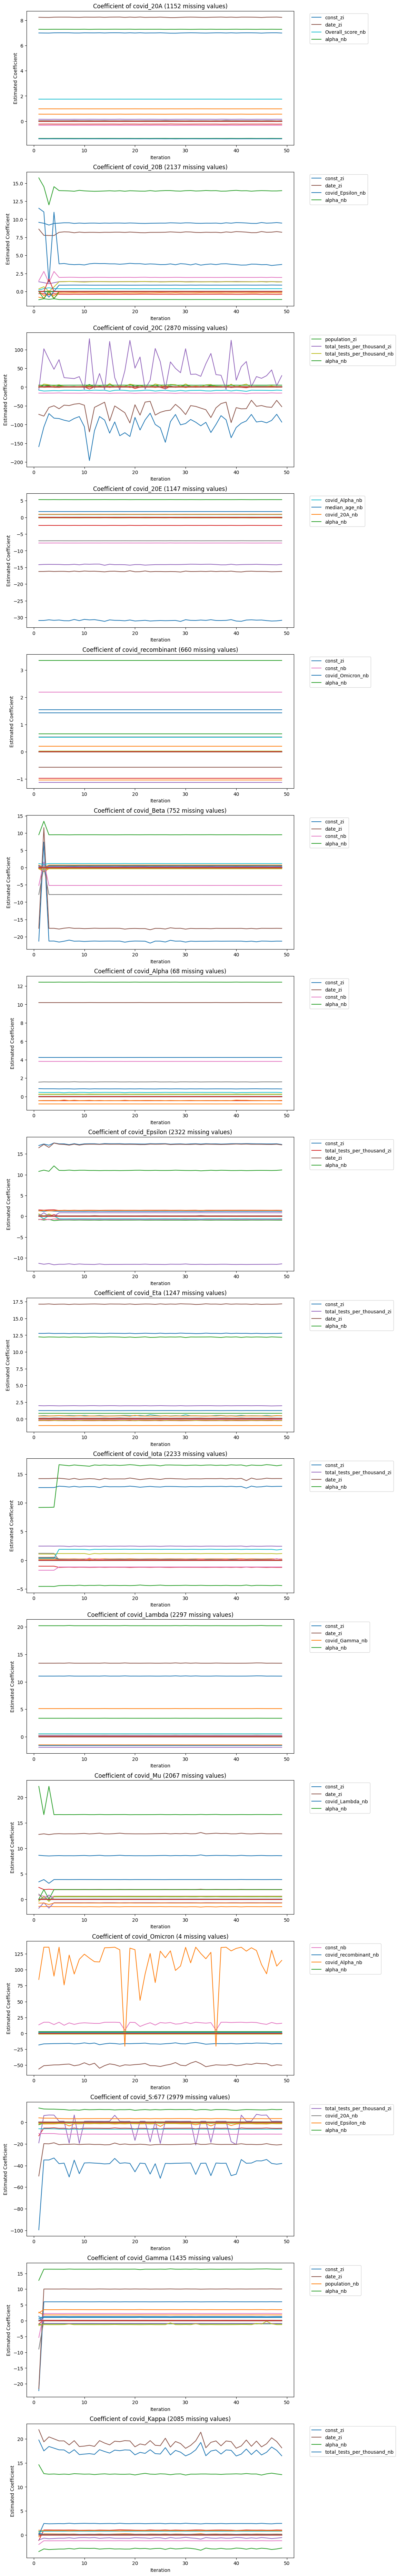

In [21]:
import matplotlib.pyplot as plt

missing_covariant_columns = [c for c in covariant_columns if c in fcs.tracker.variables]

plt.figure(figsize=(10, 6 * len(missing_covariant_columns)))
for idx, covariant_col in enumerate(missing_covariant_columns):
    plt.subplot(len(missing_covariant_columns), 1, idx + 1)

    coefficients_over_iterations = {}

    var_history = fcs.tracker.variables[covariant_col].history

    for record in var_history:
        for param in record.params:
            par_name = param.name
            par_value = param.value
            par_type = param.component
            type_key = f"{par_name}_{par_type}"

            if type_key not in coefficients_over_iterations:
                coefficients_over_iterations[type_key] = []
            coefficients_over_iterations[type_key].append(par_value)
    
    sorted_by_max = sorted(
        coefficients_over_iterations.items(), 
        key=lambda item: max(item[1]), 
        reverse=True
    )

    top_values = [item[0] for item in sorted_by_max[:4]]

    # coefficients_over_iterations
    iterations = range(1, len(var_history))
    for predictor, values in coefficients_over_iterations.items():
        # max value = max(values)
        if predictor in top_values:
            plt.plot(iterations, values, label=f"{predictor}")
        else:
            plt.plot(iterations, values)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.xlabel('Iteration')
    plt.ylabel('Estimated Coefficient')
    plt.title(f'Coefficient of {covariant_col} ({len(var_history[0].imputed_values)} missing values)')
plt.show()

### 5.2 Plot average imputed values of each variable across iterations

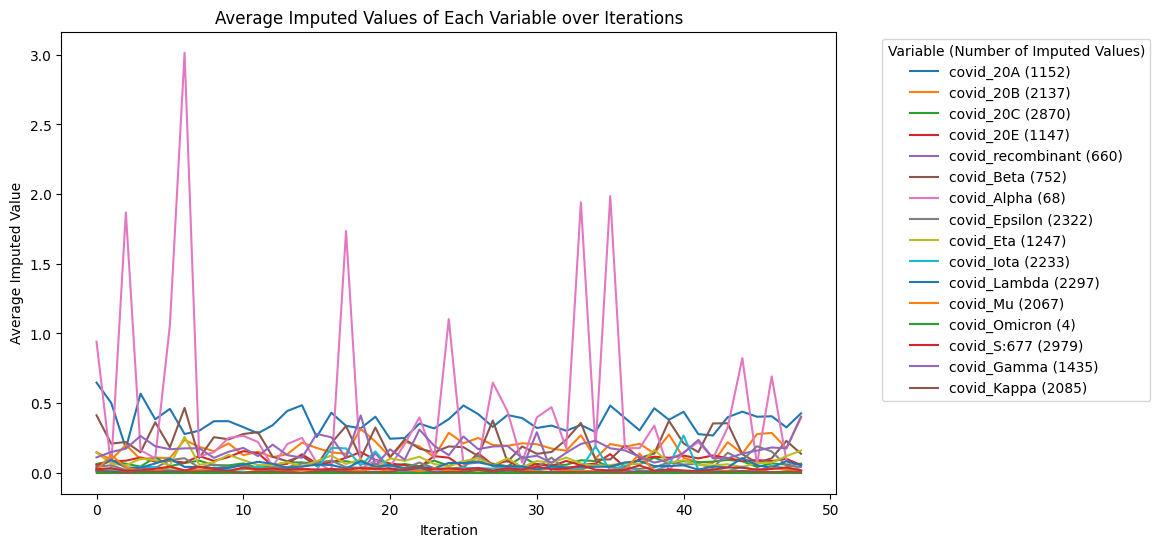

In [22]:
plt.figure(figsize=(10, 6))

for var_name, var_history in fcs.tracker.variables.items():
    avg_imputed_values = [np.mean(record.imputed_values) for record in var_history.history[1:]]  # skip initialization
    plt.plot(avg_imputed_values, label=f"{var_name} ({len(var_history.history[-1].imputed_values)})")

plt.xlabel('Iteration')
plt.ylabel('Average Imputed Value')
plt.title('Average Imputed Values of Each Variable over Iterations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Variable (Number of Imputed Values)")
plt.show()

## 6. Analyze specific case - Alpha variant

- **Alpha**: extremely high imputed values and large oscillation.

In [23]:
var_name = 'covid_Alpha'
variable = next(v for v in zinb_variables if v.name == var_name)
var_history = fcs.tracker.variables[var_name]

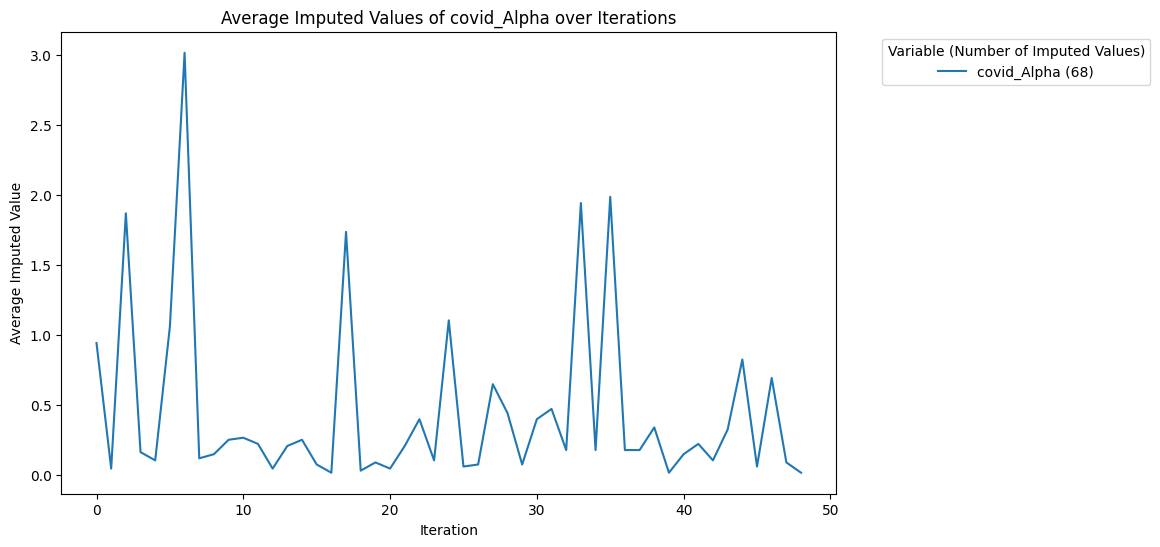

In [24]:
plt.figure(figsize=(10, 6))

avg_imputed_values = [np.mean(record.imputed_values) for record in var_history.history[1:]]  # skip initialization
plt.plot(avg_imputed_values, label=f"{var_name} ({len(var_history.history[-1].imputed_values)})")

plt.xlabel('Iteration')
plt.ylabel('Average Imputed Value')
plt.title(f'Average Imputed Values of {var_name} over Iterations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Variable (Number of Imputed Values)")
plt.show()

### Check rows with non-zero imputed values

In [25]:
# create a dataframe to summarize the imputed values
## x-axis: iteration
## y-axis: imputed value of different rows
alpha_imputed_values = np.zeros((len(var_history.history), len(variable.missing_indices)))  # shape (iterations, missing_values)

for i, record in enumerate(var_history.history):  # skip initialization
    imputed_value = record.imputed_values
    alpha_imputed_values[i, :] = imputed_value

alpha_df = pd.DataFrame(alpha_imputed_values.T, columns=[f"Iter {i}" for i in range(len(var_history.history))])
alpha_df['row index'] = variable.missing_indices

# show list of rows having non-zero imputed values (any iteration)
alpha_df[alpha_df.iloc[:, :-1].any(axis=1)]

,Iter 0,Iter 1,Iter 2,Iter 3,Iter 4,Iter 5,Iter 6,Iter 7,Iter 8,Iter 9,...,Iter 41,Iter 42,Iter 43,Iter 44,Iter 45,Iter 46,Iter 47,Iter 48,Iter 49,row index
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1155
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1156
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,1157
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1158
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1159
5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1160
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1161
7,0.0,0.0,0.0,2.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1162
8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1163
10,0.0,4.0,0.0,0.0,3.0,0.0,0.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1165


### Check estimated parameters of the non-zero imputation rows

- **Zero-inflation**: probability of being zero.
- **Count model**: $n, p$ parameters of the negative binomial distribution.

### Check mu of the imputed rows across iterations

In [26]:
alpha_mu = np.zeros((len(var_history.history[1:]), len(variable.missing_indices)))  # shape (iterations, missing_values)

for i, record in enumerate(var_history.history[1:]):  # skip initialization
    mu_values = [dist.mu for dist in record.distributions]
    alpha_mu[i, :] = mu_values

alpha_df = pd.DataFrame(alpha_mu.T, columns=[f"Iter {i+1}" for i in range(len(var_history.history[1:]))])
alpha_df['row index'] = variable.missing_indices

# show list of rows having non-zero imputed values (any iteration)
alpha_df[alpha_df.iloc[:, :-1].any(axis=1)]

,Iter 1,Iter 2,Iter 3,Iter 4,Iter 5,Iter 6,Iter 7,Iter 8,Iter 9,Iter 10,...,Iter 41,Iter 42,Iter 43,Iter 44,Iter 45,Iter 46,Iter 47,Iter 48,Iter 49,row index
0,64.329782,64.105024,64.509566,64.254726,64.821521,64.203551,64.575219,64.600128,64.546798,63.891401,...,64.564934,77.232569,64.679996,64.463193,64.500307,64.358084,64.485527,64.552949,64.538102,1155
1,64.329782,69.983075,64.509566,64.254726,64.821521,64.203551,64.575219,64.600128,64.546798,63.891401,...,64.564934,64.924873,64.679996,64.463193,64.500307,64.358084,64.485527,64.552949,64.538102,1156
2,59.322961,59.091629,59.433504,59.224938,59.686239,59.190004,59.490256,59.486071,59.469831,58.952655,...,59.465943,59.731254,59.578122,58.837165,59.421633,59.304021,59.408409,59.467808,59.441760,1157
3,60.535239,60.305310,60.662111,60.442551,60.928905,60.403781,60.720988,60.723630,66.259482,60.148713,...,60.699953,60.987634,60.812879,60.629903,60.650846,60.527383,60.637249,66.235609,60.675134,1158
4,59.922758,59.692105,60.041345,59.827356,60.301013,59.790532,60.099146,60.098321,60.077790,59.544449,...,60.076445,60.352780,60.188997,60.011354,60.029772,59.909273,60.016363,60.076711,60.051948,1159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,48.942920,48.704965,48.926088,48.805674,49.066453,48.800829,48.965508,48.909092,48.959950,48.703974,...,48.916519,49.005733,49.020914,48.932272,48.909789,48.839199,48.899671,48.943261,48.897662,11639
64,48.942920,48.704965,48.926088,48.805674,49.066453,48.800829,53.453180,48.909092,48.959950,48.703974,...,48.916519,49.005733,49.020914,48.932272,48.909789,48.839199,48.899671,48.943261,48.897662,11640
65,105.864861,107.004839,106.845320,107.011231,107.129859,106.957998,106.989671,108.105842,106.939458,106.674891,...,107.183380,107.438572,106.562711,106.543726,107.402286,107.349248,107.488224,107.136997,107.614647,11643
66,5660.488346,6179.827574,6000.526720,6121.360839,6019.888342,6103.051579,6025.628751,6448.465539,6010.793813,6053.280724,...,6123.906144,8735.974238,5855.654420,5894.089192,6197.640034,6219.559855,6233.003984,6088.544274,6281.741623,11644


### Check pi of the imputed rows across iterations

In [27]:
alpha_pi = np.zeros((len(var_history.history[1:]), len(variable.missing_indices)))  # shape (iterations, missing_values)

for i, record in enumerate(var_history.history[1:]):  # skip initialization
    pi_values = [dist.pi for dist in record.distributions]
    alpha_pi[i, :] = pi_values

alpha_pi_df = pd.DataFrame(alpha_pi.T, columns=[f"Iter {i+1}" for i in range(len(var_history.history[1:]))])
alpha_pi_df['row index'] = variable.missing_indices

# show list of rows having non-zero imputed values (any iteration)
alpha_pi_df[alpha_pi_df.iloc[:, :-1].any(axis=1)]

,Iter 1,Iter 2,Iter 3,Iter 4,Iter 5,Iter 6,Iter 7,Iter 8,Iter 9,Iter 10,...,Iter 41,Iter 42,Iter 43,Iter 44,Iter 45,Iter 46,Iter 47,Iter 48,Iter 49,row index
0,0.583785,0.583876,0.583649,0.583746,0.583562,0.583809,0.583620,0.583610,0.583644,0.584040,...,0.583577,0.575317,0.583581,0.583703,0.583634,0.583669,0.583645,0.583631,0.583627,1155
1,0.583786,0.579771,0.583650,0.583747,0.583562,0.583810,0.583621,0.583611,0.583645,0.584041,...,0.583578,0.583404,0.583582,0.583704,0.583635,0.583670,0.583646,0.583632,0.583628,1156
2,0.587605,0.587718,0.587513,0.587590,0.587450,0.587643,0.587485,0.587498,0.587505,0.587836,...,0.587455,0.587332,0.587453,0.588009,0.587500,0.587525,0.587511,0.587499,0.587504,1157
3,0.586653,0.586760,0.586550,0.586632,0.586480,0.586687,0.586522,0.586529,0.582423,0.586890,...,0.586488,0.586352,0.586488,0.586595,0.586536,0.586564,0.586547,0.582432,0.586538,1158
4,0.587136,0.587246,0.587039,0.587119,0.586973,0.587173,0.587011,0.587021,0.587032,0.587370,...,0.586979,0.586850,0.586978,0.587082,0.587026,0.587052,0.587037,0.587024,0.587029,1159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,0.597009,0.597172,0.597021,0.597052,0.597018,0.597082,0.597000,0.597064,0.597009,0.597180,...,0.596999,0.596996,0.596982,0.597034,0.597015,0.597018,0.597026,0.597017,0.597047,11639
64,0.597115,0.597278,0.597127,0.597158,0.597124,0.597188,0.592918,0.597170,0.597115,0.597285,...,0.597105,0.597102,0.597088,0.597140,0.597121,0.597124,0.597132,0.597123,0.597153,11640
65,0.561969,0.561411,0.561550,0.561386,0.561574,0.561435,0.561508,0.561051,0.561533,0.561558,...,0.561373,0.561356,0.561727,0.561697,0.561293,0.561243,0.561258,0.561441,0.561226,11643
66,0.409264,0.406316,0.407358,0.406598,0.407425,0.406727,0.407245,0.405058,0.407329,0.406997,...,0.406656,0.395395,0.408222,0.407964,0.406281,0.406081,0.406097,0.406902,0.405870,11644


## 7. Export dataset with imputed values

In [28]:
imputed_data = imputed_df[['iso_code', 'date'] + covariant_columns].copy()
imputed_data.rename(columns={col: col[len("covid_"):] for col in covariant_columns}, inplace=True)

new_covariant_columns = [col[len("covid_"):] for col in covariant_columns]

final_df = pd.concat(
    [original_df.drop(columns=new_covariant_columns), imputed_data[new_covariant_columns]],
    axis=1
)

final_df.info()

# Export the final imputed dataset
stored_path = "data/processed/covariant_full_imputed.csv"
if not os.path.exists(os.path.dirname(stored_path)):
    os.makedirs(os.path.dirname(stored_path), exist_ok=True)

final_df.to_csv(stored_path, index=False)
print(f"Final imputed dataset saved to: {stored_path}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11671 entries, 0 to 11670
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   iso_code                        11671 non-null  object 
 1   continent                       11671 non-null  object 
 2   location                        11671 non-null  object 
 3   date                            11671 non-null  object 
 4   new_cases_smoothed_per_million  11671 non-null  float64
 5   population                      11671 non-null  float64
 6   median_age                      11671 non-null  float64
 7   classification                  11671 non-null  object 
 8   Overall_score                   11671 non-null  float64
 9   group                           11671 non-null  object 
 10  total_sequence                  11671 non-null  int64  
 11  total_tests_per_thousand        11671 non-null  float64
 12  people_vaccinated_per_hundred   